<a href="https://colab.research.google.com/github/SimonAlcaraz/README/blob/main/DataScience_Alcaraz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#***Contexto del problema y origen del dataset***

##Contexto del Problema de Negocio

En la industria de las telecomunicaciones (Telco), la retención de clientes representa uno de los desafíos estratégicos y financieros más críticos. La cancelación del servicio o pérdida de clientes (Customer Churn) afecta de forma directa el flujo de ingresos recurrentes y disminuye la rentabilidad general de la compañía.

##Origen y Descripción del Dataset

Para llevar a cabo este análisis se utiliza el conjunto de datos público Telco Customer Churn, provisto originalmente por IBM Cognos Analytics y ampliamente adoptado como benchmark profesional para problemas de ciencia de datos aplicados a negocios.

    Fuente: Repositorio oficial de IBM / GitHub.

#***Carga del Dataset***

##*Importación de librerias*

In [31]:
# Importamos la librería numpy con el apodo np
import numpy as np

# Importamos la librería pandas con el apodo pd
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

##*Carga de datos y dataset*

In [32]:
url= "https://raw.githubusercontent.com/Geo-y20/Telco-Customer-Churn-/refs/heads/main/Telco%20Customer%20Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [35]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [36]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [37]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [38]:
print("Filas duplicadas",df.duplicated().sum())

Filas duplicadas 0


**Observaciones iniciales:**


*   El dataset tiene 7043 registros y 21 columnas, sin valores nulos explícitos `NaN`.
*    No se detectan filas duplicadas.
*    Notamos la columna `TotalCharges` la cual figura como `object`, debe ser un `float64` de acuerdo a las caracteristicas que quiere comunicar; va a ser analizada en la etapa de limpieza.









# Analisis Explolatorio de Datos (EDA)

In [39]:
# Conversión forzada de TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
print(f"Tipo corregido de TotalCharges: {df['TotalCharges'].dtype}\n")

Tipo corregido de TotalCharges: float64



In [40]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Notamos que convirtiendo la variable `TotalCharges` a `float64` y viendo si hay valores nulos, notamos 11 valores nulos.
Vamos a analizar que responde ese patrón y evaluar en caso de eliminar esos casos.

In [41]:
#Filtramos las filas con TotalCharges nulo y seleccionamos columnas relevantes
cruce_nulos = df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract']]

print("CRUCE DE VARIABLES PARA REGISTROS CON TOTALCHARGES NULO")
display(cruce_nulos)

# Resumen de frecuencia de tenure para confirmar la regla de negocio
print("\nDistribución de antigüedad (tenure) en los registros nulos:")
print(df[df['TotalCharges'].isna()]['tenure'].value_counts())

CRUCE DE VARIABLES PARA REGISTROS CON TOTALCHARGES NULO


,tenure,MonthlyCharges,TotalCharges,Churn,Contract
488,0,52.55,NaN,No,Two year
753,0,20.25,NaN,No,Two year
936,0,80.85,NaN,No,Two year
1082,0,25.75,NaN,No,Two year
1340,0,56.05,NaN,No,Two year
3331,0,19.85,NaN,No,Two year
3826,0,25.35,NaN,No,Two year
4380,0,20.00,NaN,No,Two year
5218,0,19.70,NaN,No,One year
6670,0,73.35,NaN,No,Two year



Distribución de antigüedad (tenure) en los registros nulos:
tenure
0    11
Name: count, dtype: int64


Al realizar el cruce de variables entre los registros con datos faltantes en `TotalCharges` y la antigüedad del cliente `tenure`, se verifica que el 100% de los valores nulos (11 casos) corresponden de manera exclusiva a usuarios con `tenure = 0`. Esto demuestra que la falta de dato no es un error de carga ni un sesgo al azar (MCAR), sino que está condicionada por la etapa del ciclo de vida del cliente (MAR: Missing at Random). Por ende, se decide conservar las 11 filas en el dataset e imputar el valor 0 o la mediana mediante SimpleImputer durante la etapa de preprocesamiento

In [42]:
df_clean[["tenure", "Contract", "MonthlyCharges", "TotalCharges", "PaymentMethod", "InternetService"]]

,tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,InternetService
0,1,Month-to-month,29.85,29.85,Electronic check,DSL
1,34,One year,56.95,1889.50,Mailed check,DSL
2,2,Month-to-month,53.85,108.15,Mailed check,DSL
3,45,One year,42.30,1840.75,Bank transfer (automatic),DSL
4,2,Month-to-month,70.70,151.65,Electronic check,Fiber optic
...,...,...,...,...,...,...
7038,24,One year,84.80,1990.50,Mailed check,DSL
7039,72,One year,103.20,7362.90,Credit card (automatic),Fiber optic
7040,11,Month-to-month,29.60,346.45,Electronic check,DSL
7041,4,Month-to-month,74.40,306.60,Mailed check,Fiber optic


#### Analisis Correspondiente de Variable Objetivo

--- Frecuencia Absoluta ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Frecuencia Porcentual (%) ---
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


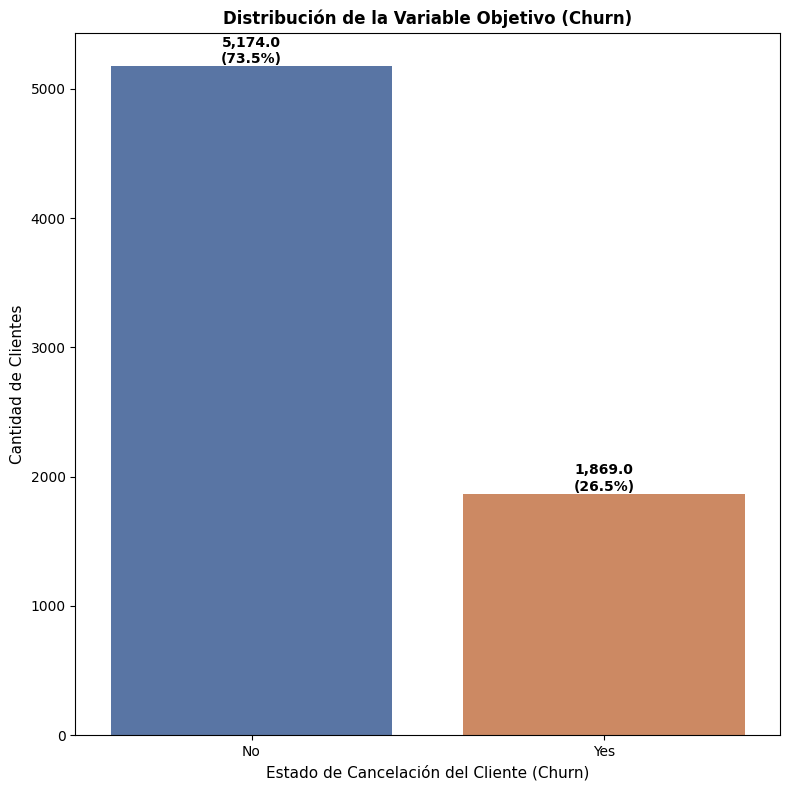

In [55]:
# 1. Cálculo de frecuencias absolutas y porcentuales
y_counts = df_clean["Churn"].value_counts()
y_pct = df_clean["Churn"].value_counts(normalize=True) * 100

print("--- Frecuencia Absoluta ---")
print(y_counts)
print("\n--- Frecuencia Porcentual (%) ---")
print(y_pct.round(2))

# 2. Generación del gráfico de barras
fig, ax = plt.subplots(figsize=(8, 8))
sns.countplot(x="Churn", data=df_clean, order=["No", "Yes"], palette=["#4C72B0", "#DD8452"], ax=ax)

# Títulos y etiquetas corregidos al contexto de Telco Churn
ax.set_title("Distribución de la Variable Objetivo (Churn)", fontsize=12, fontweight="bold")
ax.set_xlabel("Estado de Cancelación del Cliente (Churn)", fontsize=11)
ax.set_ylabel("Cantidad de Clientes", fontsize=11)

# Anotación de la cantidad de clientes sobre cada barra
for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_clean)) * 100
    ax.annotate(f"{height:,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Conclusión del Análisis de la Variable Objetivo**

El diagnóstico de la variable dependiente revela un **desbalance de clases pronunciado**: únicamente el 11.5% de las interacciones resultaron en la aceptación de un depósito a plazo fijo, mientras que el 88.5% restante corresponde a respuestas negativas. Esta proporción refleja fielmente la problemática de negocio señalada por la institución bancaria respecto al bajo rendimiento de las campañas telefónicas.

Este fenómeno condiciona directamente la estrategia metodológica del proyecto:
*   Métricas de Evaluación: Se descarta el **Accuracy** como indicador principal, dado que un modelo iluso que clasifique la totalidad de los casos como "No" alcanzaría un 88.5% de exactitud sin generar valor operativo ni identificar prospectos reales. En su lugar, la optimización se enfocará en **Recall**, **Precision**, **F1-Score** y **ROC-AUC**.
*   Estrategia de Muestreo y Validación: Se aplicará división estratificada (Stratified K-Fold) tanto en el split de entrenamiento/prueba como en la validación cruzada para garantizar la representatividad de la clase minoritaria en cada iteración.
*   Ajuste de Algoritmos: Se implementarán técnicas de ponderación de costo (class_weight="balanced" o sample weights) para penalizar los errores en la clase positiva y obligar a los algoritmos a priorizar la detección de los clientes propensos a aceptar el depósito.

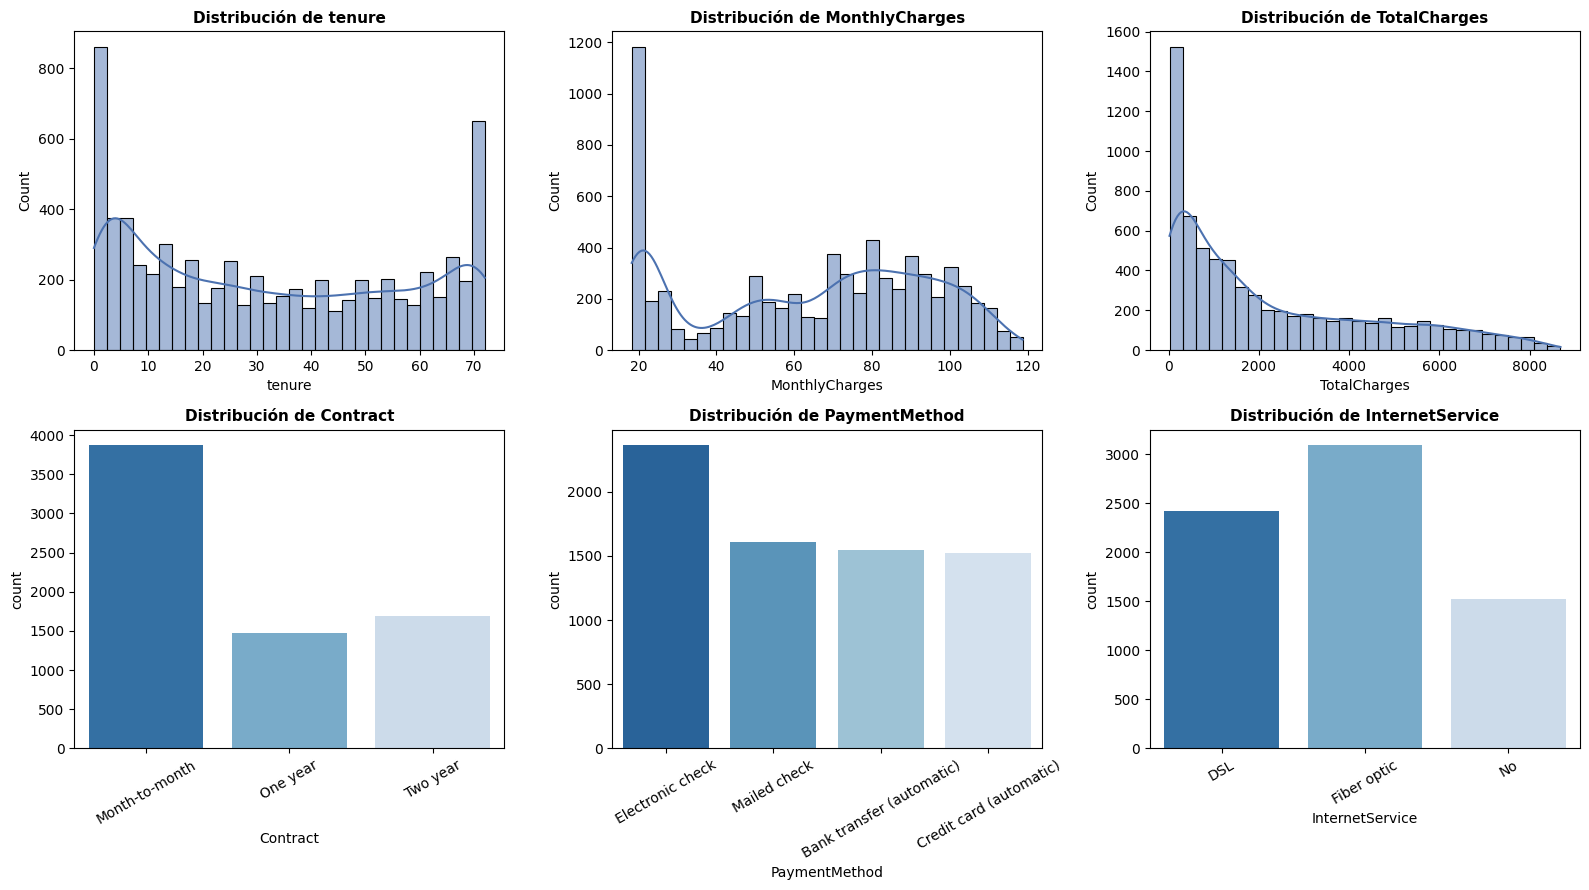

In [58]:
# Separación clara por tipo de dato
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = ["Contract", "PaymentMethod", "InternetService"]

all_features = num_cols + cat_cols

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(all_features):
    if col in num_cols:
        # Histograma para variables numéricas
        sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[i], color="#4C72B0")
    else:
        # Gráfico de barras para variables categóricas
        sns.countplot(x=df_clean[col], ax=axes[i], palette="Blues_r")
        axes[i].tick_params(axis='x', rotation=30) # Rotar etiquetas para facilitar lectura

    axes[i].set_title(f"Distribución de {col}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

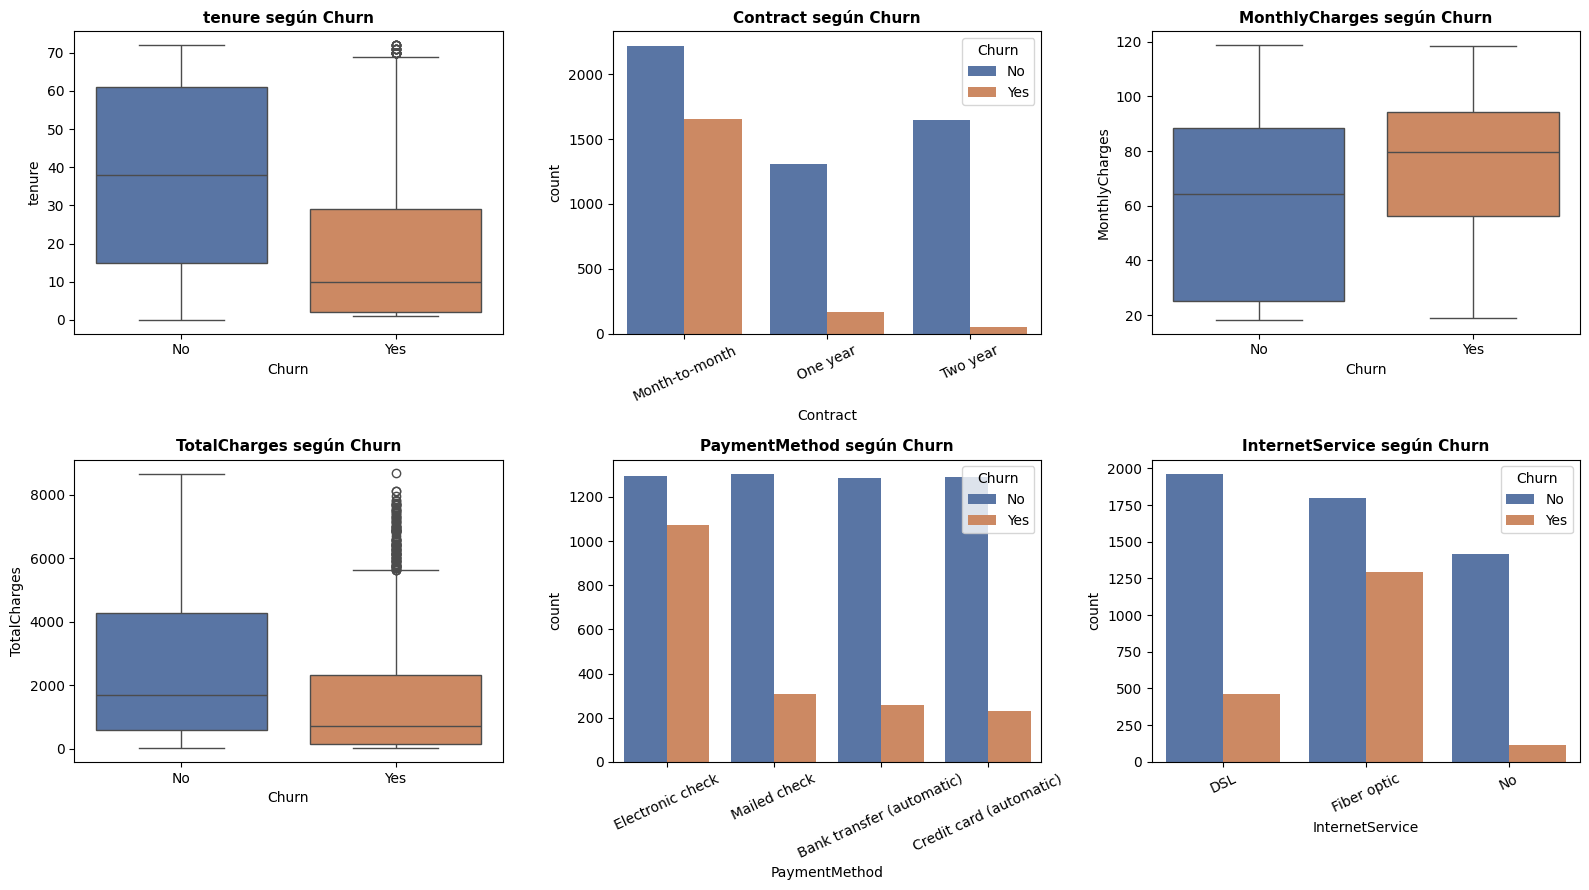

In [61]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = ["Contract", "PaymentMethod", "InternetService"]

all_cols = ["tenure", "Contract", "MonthlyCharges", "TotalCharges", "PaymentMethod", "InternetService"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    if col in num_cols:
        # Boxplot para numéricas
        sns.boxplot(x="Churn", y=col, data=df_clean, order=["No", "Yes"],
                    palette=["#4C72B0", "#DD8452"], ax=axes[i])
    else:
        # Countplot normalizado / barrado para categóricas
        sns.countplot(x=col, hue="Churn", data=df_clean, hue_order=["No", "Yes"],
                      palette=["#4C72B0", "#DD8452"], ax=axes[i])
        axes[i].tick_params(axis='x', rotation=25)

    axes[i].set_title(f"{col} según Churn", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()